In [1]:
import pandas as pd
import sklearn as sk

In [2]:
import pandas as pd
import glob

# Encontra todos os arquivos .csv no diretório atual
arquivos_csv = glob.glob('*.csv')

# Lista para armazenar os DataFrames temporários
lista_dfs = []

for arquivo in arquivos_csv:
    # Lê cada arquivo e adiciona à lista
    df_temp = pd.read_csv(arquivo)
    lista_dfs.append(df_temp)

# Verifica se a lista não está vazia antes de concatenar
if lista_dfs:
    # Concatena todos os DataFrames em um só
    # ignore_index=True garante que o índice final seja contínuo (0, 1, 2...)
    df_final = pd.concat(lista_dfs, ignore_index=True)
    print(f"Sucesso! {len(arquivos_csv)} arquivos concatenados.")
    print(df_final.head())
else:
    print("Nenhum arquivo .csv foi encontrado no diretório atual.")

Sucesso! 12 arquivos concatenados.
                                     id      lat      lon  \
0  966ed445-fa70-3369-9802-3e74c5765684 -12.5667 -41.4364   
1  0669c14d-7a39-3d98-9f20-23e118fbcf09 -12.5662 -41.4611   
2  53a46800-fa40-3323-9b20-05108d435c24 -18.0629 -57.3721   
3  7e692d84-dc67-348c-95e1-9e67a129b2db -18.0625 -57.3927   
4  267ae531-1d2c-3434-9280-7e3ba76fc896 -18.0629 -57.3721   

         data_hora_gmt satelite municipio              estado    pais  \
0  2024-01-01 00:00:00  GOES-16   LENÇÓIS               BAHIA  Brasil   
1  2024-01-01 00:00:00  GOES-16   LENÇÓIS               BAHIA  Brasil   
2  2024-01-01 00:00:00  GOES-16   CORUMBÁ  MATO GROSSO DO SUL  Brasil   
3  2024-01-01 00:00:00  GOES-16   CORUMBÁ  MATO GROSSO DO SUL  Brasil   
4  2024-01-01 01:00:00  GOES-16   CORUMBÁ  MATO GROSSO DO SUL  Brasil   

   municipio_id  estado_id  ...  quantidade_ocorrencias  temperatura  \
0       2919306         29  ...                       1         26.0   
1       2919306

In [5]:
df_final = df_final[(df_final['pais'] == 'Brasil') & ((df_final['bioma'] == 'Cerrado') | (df_final['bioma'] == 'Mata Atlântica'))]

In [8]:
df_final.columns

Index(['id', 'lat', 'lon', 'data_hora_gmt', 'satelite', 'municipio', 'estado',
       'pais', 'municipio_id', 'estado_id', 'pais_id', 'numero_dias_sem_chuva',
       'precipitacao', 'risco_fogo', 'bioma', 'frp', 'quantidade_ocorrencias',
       'temperatura', 'cobertura_nuvens', 'ponto_orvalho_2m', 'pressao_msl',
       'radiacao_direta', 'radiacao_ondas_curtas', 'umidade_solo_0_a_7cm',
       'temperatura_solo_0_a_7cm', 'rajadas_vento_10m'],
      dtype='str')

In [6]:
df_colunas_prontas = df_final[['temperatura', 'umidade_solo_0_a_7cm','bioma', 'risco_fogo']]

In [7]:
df_colunas_prontas.dropna(inplace=True)

In [8]:
df_colunas_prontas.columns = ['temperatura', 'umidade', 'bioma', 'risco_fogo']

In [9]:
df_colunas_prontas

,temperatura,umidade,bioma,risco_fogo
10,26.6,0.166,Mata Atlântica,1.0000
11,24.4,0.234,Mata Atlântica,0.4125
12,24.4,0.234,Mata Atlântica,0.5900
13,25.2,0.175,Mata Atlântica,0.3400
14,23.8,0.295,Mata Atlântica,0.7400
...,...,...,...,...
3247994,33.2,0.238,Mata Atlântica,0.8600
3247995,33.2,0.349,Cerrado,1.0000
3247996,33.8,0.358,Mata Atlântica,0.9600
3247997,33.2,0.349,Cerrado,1.0000


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

df_preparado = pd.get_dummies(df_colunas_prontas, columns=['bioma'], drop_first=True)



In [11]:
X = df_preparado.drop('risco_fogo', axis=1)
y = df_preparado['risco_fogo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [12]:
modelo_arvore = DecisionTreeRegressor(random_state=42)
modelo_arvore.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with

In [13]:
previsoes = modelo_arvore.predict(X_test)

mse = mean_squared_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")

Erro Quadrático Médio (MSE): 0.0529
R² (Coeficiente de Determinação): 0.4301


Tabela de Comparação (Primeiras 15 amostras):
    Valor Real  Previsão  Erro Absoluto
0         1.00  1.000000       0.000000
1         0.81  0.823889       0.013889
2         0.46  0.961129       0.501129
3         1.00  0.992959       0.007041
4         1.00  1.000000       0.000000
5         1.00  1.000000       0.000000
6         1.00  1.000000       0.000000
7         1.00  1.000000       0.000000
8         1.00  0.991707       0.008293
9         0.27  1.000000       0.730000
10        0.83  0.205000       0.625000
11        1.00  0.897162       0.102838
12        1.00  1.000000       0.000000
13        1.00  0.617167       0.382833
14        1.00  0.848524       0.151476


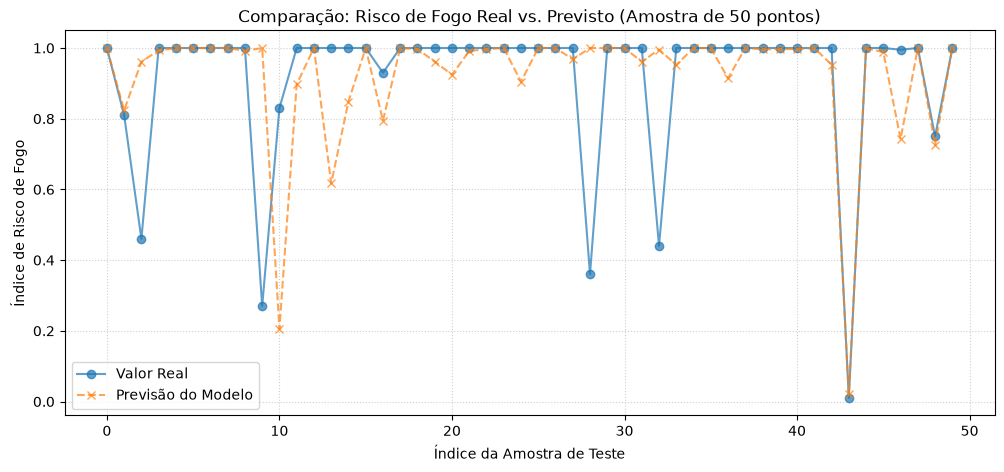

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Criar um DataFrame para alinhar os valores reais e previstos
# Utilizamos .values no y_test para ignorar os índices originais desordenados
df_comparacao = pd.DataFrame({
    'Valor Real': y_test.values,
    'Previsão': previsoes
})

# 2. Calcular a diferença absoluta (erro)
df_comparacao['Erro Absoluto'] = abs(df_comparacao['Valor Real'] - df_comparacao['Previsão'])

# 3. Mostrar as primeiras 15 previsões no ecrã
print("Tabela de Comparação (Primeiras 15 amostras):")
print(df_comparacao.head(15))

# 4. Criar um gráfico para visualizar os primeiros 50 casos
plt.figure(figsize=(12, 5))
plt.plot(df_comparacao['Valor Real'][:50], label='Valor Real', marker='o', linestyle='-', alpha=0.7)
plt.plot(df_comparacao['Previsão'][:50], label='Previsão do Modelo', marker='x', linestyle='--', alpha=0.7)

plt.title('Comparação: Risco de Fogo Real vs. Previsto (Amostra de 50 pontos)')
plt.xlabel('Índice da Amostra de Teste')
plt.ylabel('Índice de Risco de Fogo')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

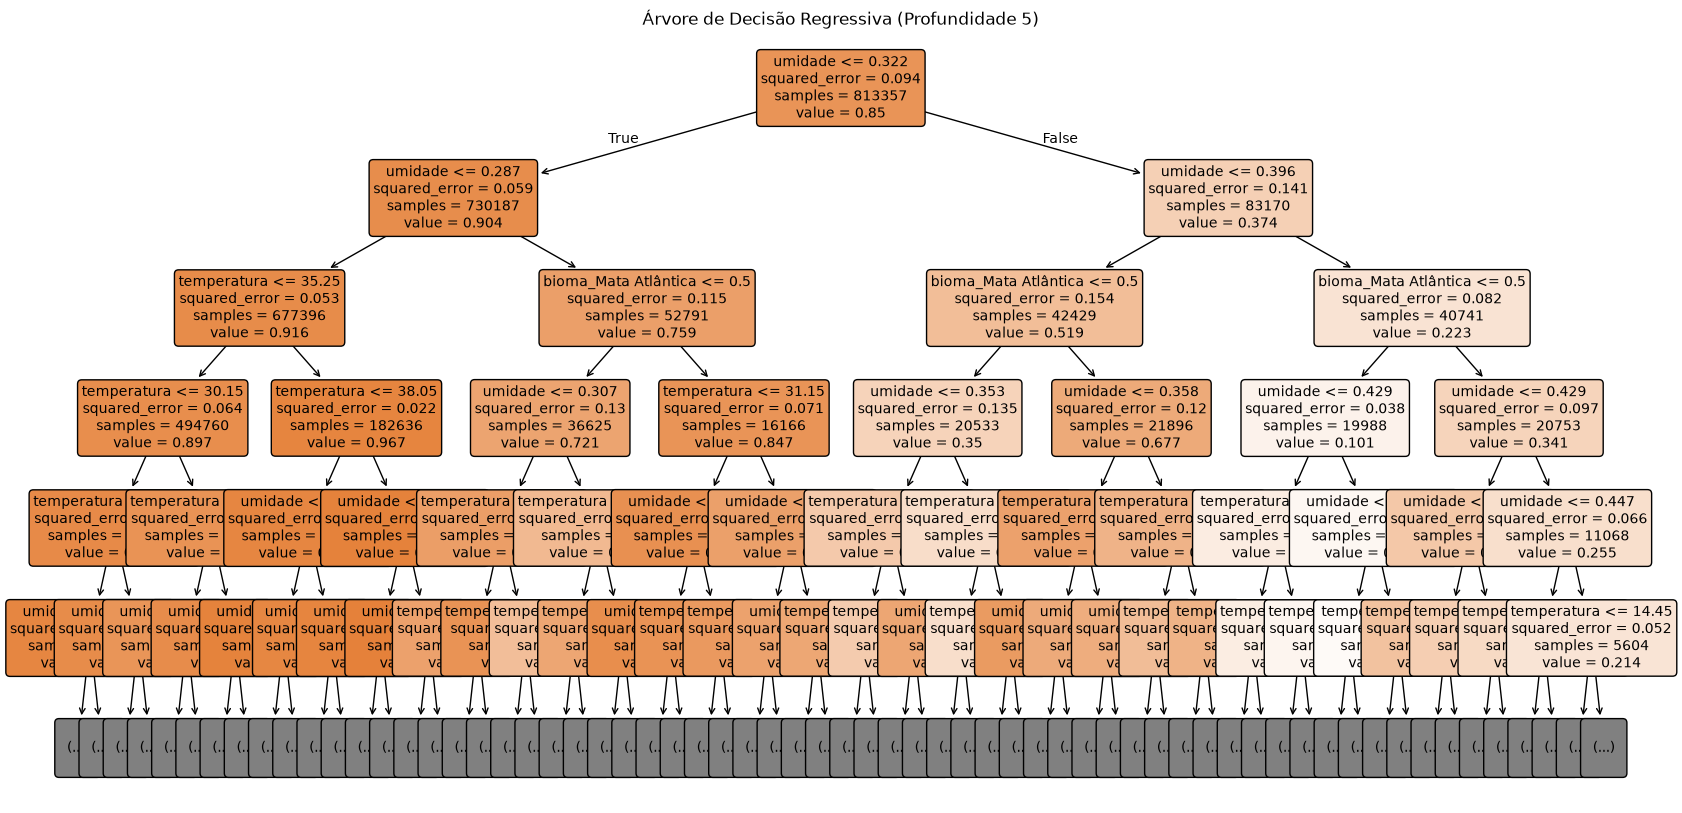

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configurar o tamanho da imagem (largura, altura)
plt.figure(figsize=(20, 10))

# Desenhar a árvore limitando a 3 níveis de profundidade para não travar
plot_tree(modelo_arvore, 
          feature_names=X.columns, # Mostra o nome das colunas nas regras
          filled=True,             # Pinta as caixas
          rounded=True,            # Arredonda as bordas
          max_depth=5,             # LIMITADOR IMPORTANTE PARA ÁRVORES GRANDES
          fontsize=10)

plt.title("Árvore de Decisão Regressiva (Profundidade 5)")
plt.show()